# Anomaly Detection with GNNs

Detect unusual nodes/graphs using embeddings from all four models.

**Approach:**
- **GCN, GraphSAGE, GIN**: Train normally (supervised), extract pre-classifier embeddings via `model.embed()`, then apply **Isolation Forest** (sklearn) to find outliers in embedding space.
- **DGI**: Same Isolation Forest approach on `embed()` embeddings **+** a DGI-specific **discriminator score** via `model.anomaly_score()` — nodes that don't match the global summary are flagged as anomalous.

**Datasets:** Cora + Karate (node-level) · Enzymes + Proteins (graph-level)

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import warnings
warnings.filterwarnings('ignore')

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import networkx as nx
from sklearn.ensemble import IsolationForest
from torch_geometric.loader import DataLoader
from torch_geometric.utils import to_networkx

from main import load_dataset, build_model, set_seed
from train import train_one_epoch, train_dgi_pretrain, train_dgi_pretrain_graph
from test import evaluate
from parameters import ModelParams, TrainParams, DataParams

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MODEL_COLORS = {'gcn': '#2196F3', 'graphsage': '#4CAF50', 'gin': '#FF9800', 'dgi': '#9C27B0'}

print('Setup complete. Device:', DEVICE)

Setup complete. Device: cuda


## Helper: Train a model
Shared training function used throughout the notebook.

In [2]:
def train_model(model_name, dataset_name, epochs=200, pretrain_epochs=300,
                lr=0.01, hidden_channels=64, num_layers=2, dropout=0.5, seed=42):
    """Train a model and return (model, ds_info, device-placed data)."""
    set_seed(seed)

    data_params  = DataParams(dataset_name=dataset_name, seed=seed)
    model_params = ModelParams(model_name=model_name, hidden_channels=hidden_channels,
                               num_layers=num_layers, dropout=dropout)
    train_params = TrainParams(lr=lr, epochs=epochs, patience=20,
                               pretrain_epochs=pretrain_epochs)

    ds_info = load_dataset(data_params)
    task = ds_info['task']

    data = train_mask = val_mask = test_mask = None
    train_loader = val_loader = test_loader = None

    if task == 'node':
        data       = ds_info['data'].to(DEVICE)
        train_mask = ds_info['train_mask'].to(DEVICE)
        val_mask   = ds_info['val_mask'].to(DEVICE)
        test_mask  = ds_info['test_mask'].to(DEVICE)
    else:
        bs = train_params.batch_size
        train_loader = DataLoader(ds_info['train_dataset'], batch_size=bs, shuffle=True)
        val_loader   = DataLoader(ds_info['val_dataset'],   batch_size=bs, shuffle=False)
        test_loader  = DataLoader(ds_info['test_dataset'],  batch_size=bs, shuffle=False)

    model = build_model(model_params, ds_info['num_features'], ds_info['num_classes'], task).to(DEVICE)

    if model_name == 'dgi':
        pre_opt = torch.optim.Adam(model.parameters(), lr=lr)
        print(f'  Pre-training DGI ({pretrain_epochs} epochs)...', end=' ', flush=True)
        for ep in range(pretrain_epochs):
            if task == 'node':
                train_dgi_pretrain(model, data, pre_opt)
            else:
                train_dgi_pretrain_graph(model, train_loader, pre_opt, DEVICE)
        print('done.')
        for param in model.dgi.encoder.parameters():
            param.requires_grad = False
        model.dgi.weight.requires_grad = False
        optimizer = torch.optim.Adam(model.classifier.parameters(), lr=lr)
    else:
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_val_acc = 0.0
    best_state   = model.state_dict()
    no_improve   = 0

    print(f'  Training {model_name.upper()} ({epochs} epochs)...', end=' ', flush=True)
    for _ in range(epochs):
        train_one_epoch(model, task, optimizer, DEVICE,
                        data=data, train_mask=train_mask, train_loader=train_loader)
        val_acc = evaluate(model, task, DEVICE, data=data, mask=val_mask, loader=val_loader)['accuracy']
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state   = model.state_dict()
            no_improve   = 0
        else:
            no_improve += 1
        if train_params.patience > 0 and no_improve >= train_params.patience:
            break

    model.load_state_dict(best_state)
    test_acc = evaluate(model, task, DEVICE, data=data, mask=test_mask, loader=test_loader)['accuracy']
    print(f'done. Val={best_val_acc:.3f}, Test={test_acc:.3f}')

    info = dict(ds_info)
    if task == 'node':
        info.update({'data': data, 'train_mask': train_mask,
                     'val_mask': val_mask, 'test_mask': test_mask})
    else:
        info.update({'train_loader': train_loader, 'val_loader': val_loader,
                     'test_loader': test_loader})
    return model, info


def isolation_forest_scores(embeddings_np):
    """Fit IsolationForest and return anomaly scores (higher = more anomalous)."""
    iso = IsolationForest(contamination=0.1, random_state=42)
    iso.fit(embeddings_np)
    # score_samples returns negative anomaly scores; invert so higher = more anomalous
    return -iso.score_samples(embeddings_np)

print('Helper functions defined.')

Helper functions defined.


---
## Part 1: Node-Level Anomaly Detection on Cora

Train all four models on Cora, extract node embeddings, detect anomalous nodes.

In [3]:
cora_models = {}
cora_info   = None

for model_name in ['gcn', 'graphsage', 'gin', 'dgi']:
    print(f'\nTraining {model_name.upper()} on Cora:')
    model, info = train_model(model_name, 'cora', epochs=150, pretrain_epochs=200)
    cora_models[model_name] = model
    cora_info = info

data_cora = cora_info['data']
labels_cora = data_cora.y.cpu().numpy()
print(f'\nCora: {data_cora.num_nodes} nodes, {data_cora.num_edges} edges, {len(set(labels_cora))} classes')


Training GCN on Cora:


Processing...


Done!


  Training GCN (150 epochs)... 

done. Val=0.784, Test=0.784

Training GRAPHSAGE on Cora:
  Training GRAPHSAGE (150 epochs)... 

done. Val=0.788, Test=0.785

Training GIN on Cora:
  Training GIN (150 epochs)... 

done. Val=0.702, Test=0.705

Training DGI on Cora:
  Pre-training DGI (200 epochs)... 

done.
  Training DGI (150 epochs)... 

done. Val=0.598, Test=0.577

Cora: 2708 nodes, 10556 edges, 7 classes


In [4]:
# Extract embeddings and compute anomaly scores for all models
cora_embeddings = {}
cora_if_scores  = {}  # Isolation Forest scores

for model_name, model in cora_models.items():
    emb = model.embed(data_cora.x, data_cora.edge_index).cpu().numpy()
    cora_embeddings[model_name] = emb
    cora_if_scores[model_name]  = isolation_forest_scores(emb)
    print(f'{model_name.upper()}: embedding shape {emb.shape}')

# DGI also gets a discriminator-based score
dgi_disc_scores = cora_models['dgi'].anomaly_score(
    data_cora.x, data_cora.edge_index
).cpu().numpy()

print(f'\nDGI discriminator score range: [{dgi_disc_scores.min():.3f}, {dgi_disc_scores.max():.3f}]')

GCN: embedding shape (2708, 64)


GRAPHSAGE: embedding shape (2708, 64)


GIN: embedding shape (2708, 64)


DGI: embedding shape (2708, 64)

DGI discriminator score range: [0.000, 0.223]


### Score Distributions per Model (Cora)
How are anomaly scores distributed across the 7 Cora classes?

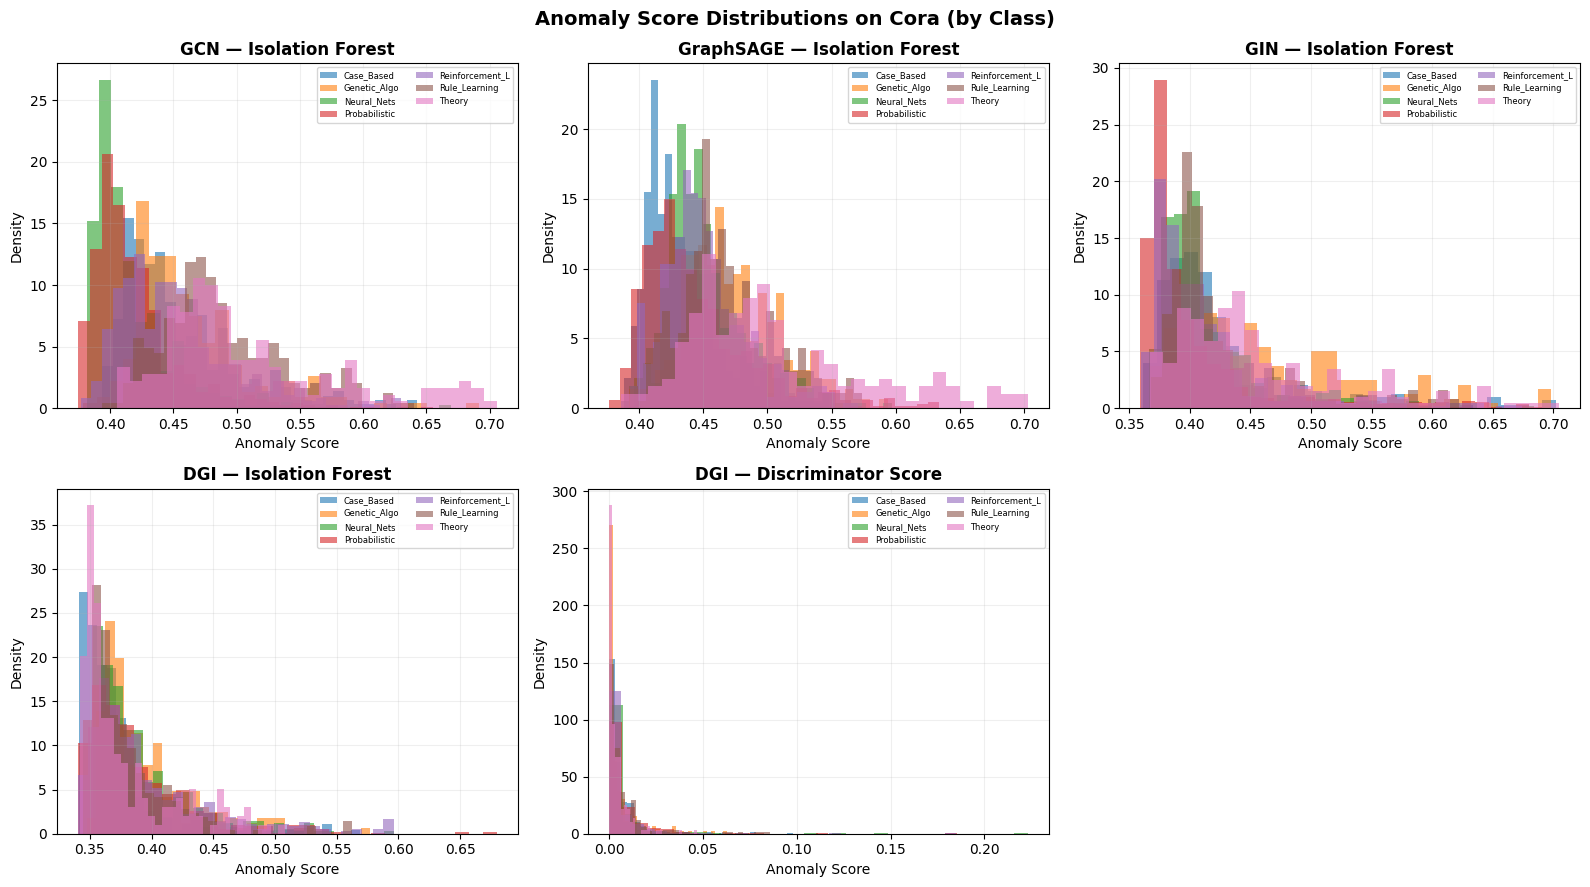

In [5]:
CLASS_NAMES = ['Case_Based', 'Genetic_Algo', 'Neural_Nets',
               'Probabilistic', 'Reinforcement_L', 'Rule_Learning', 'Theory']
CLASS_PALETTE = plt.cm.tab10.colors

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes_flat = axes.flat

plot_entries = [
    ('gcn',       cora_if_scores['gcn'],       'GCN — Isolation Forest'),
    ('graphsage', cora_if_scores['graphsage'],  'GraphSAGE — Isolation Forest'),
    ('gin',       cora_if_scores['gin'],        'GIN — Isolation Forest'),
    ('dgi',       cora_if_scores['dgi'],        'DGI — Isolation Forest'),
    ('dgi',       dgi_disc_scores,              'DGI — Discriminator Score'),
]

for ax, (model_name, scores, title) in zip(axes_flat, plot_entries):
    for cls_idx in range(7):
        mask = labels_cora == cls_idx
        ax.hist(scores[mask], bins=30, alpha=0.6,
                label=CLASS_NAMES[cls_idx], color=CLASS_PALETTE[cls_idx], density=True)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Anomaly Score')
    ax.set_ylabel('Density')
    ax.legend(fontsize=6, ncol=2)
    ax.grid(True, alpha=0.2)

# Hide unused subplot
axes[1, 2].set_visible(False)

plt.suptitle('Anomaly Score Distributions on Cora (by Class)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('cora_score_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

### Top-20 Most Anomalous Nodes (Cora)

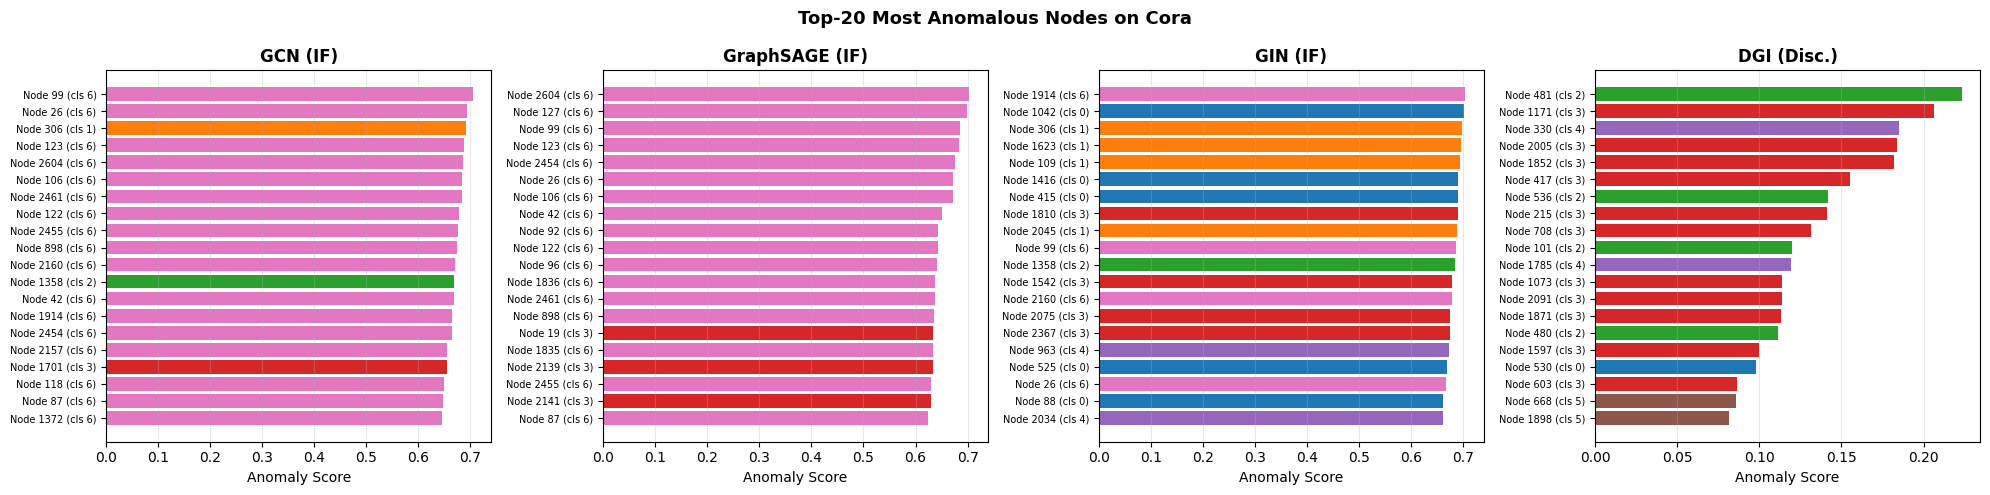

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

all_scores = [
    ('GCN (IF)',        cora_if_scores['gcn']),
    ('GraphSAGE (IF)',  cora_if_scores['graphsage']),
    ('GIN (IF)',        cora_if_scores['gin']),
    ('DGI (Disc.)',     dgi_disc_scores),
]

for ax, (title, scores) in zip(axes, all_scores):
    top20_idx  = np.argsort(scores)[-20:][::-1]
    top20_cls  = labels_cora[top20_idx]
    top20_scr  = scores[top20_idx]
    colors_bar = [CLASS_PALETTE[c] for c in top20_cls]
    ax.barh(range(20), top20_scr, color=colors_bar)
    ax.set_yticks(range(20))
    ax.set_yticklabels([f'Node {i} (cls {c})' for i, c in zip(top20_idx, top20_cls)], fontsize=7)
    ax.set_xlabel('Anomaly Score')
    ax.set_title(title, fontweight='bold')
    ax.invert_yaxis()
    ax.grid(True, axis='x', alpha=0.3)

plt.suptitle('Top-20 Most Anomalous Nodes on Cora', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cora_top20_anomalous.png', dpi=120, bbox_inches='tight')
plt.show()

### DGI: Isolation Forest vs Discriminator Score Agreement
Do the two DGI anomaly methods agree on which nodes are anomalous?

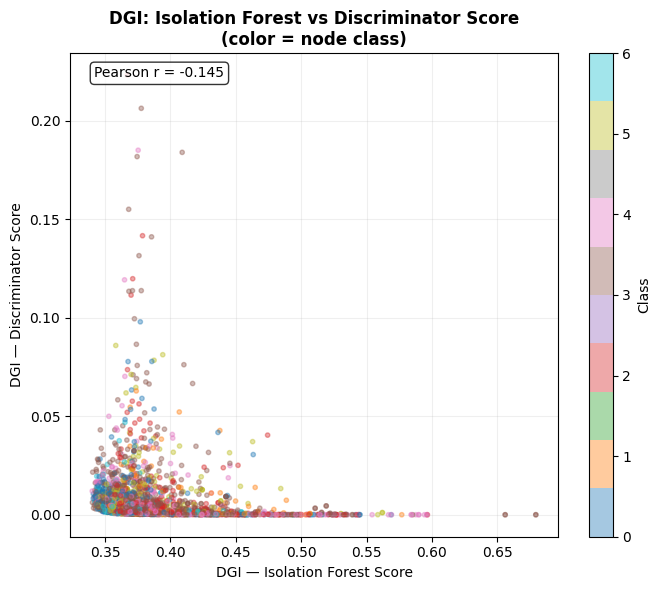

Correlation between IF and discriminator scores: -0.145


In [7]:
fig, ax = plt.subplots(figsize=(7, 6))
scatter = ax.scatter(
    cora_if_scores['dgi'], dgi_disc_scores,
    c=labels_cora, cmap='tab10', alpha=0.4, s=10
)
ax.set_xlabel('DGI — Isolation Forest Score')
ax.set_ylabel('DGI — Discriminator Score')
ax.set_title('DGI: Isolation Forest vs Discriminator Score\n(color = node class)', fontweight='bold')
plt.colorbar(scatter, ax=ax, ticks=range(7), label='Class')
corr = np.corrcoef(cora_if_scores['dgi'], dgi_disc_scores)[0, 1]
ax.text(0.05, 0.95, f'Pearson r = {corr:.3f}', transform=ax.transAxes,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('dgi_method_agreement.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Correlation between IF and discriminator scores: {corr:.3f}')

---
## Part 2: Karate Club Graph Visualization
Train all models on Karate Club and visualize the graph with nodes colored by anomaly score.
The Karate Club is small (34 nodes) and easy to visualize.

In [8]:
karate_models = {}
karate_info   = None

for model_name in ['gcn', 'graphsage', 'gin', 'dgi']:
    print(f'Training {model_name.upper()} on Karate...')
    model, info = train_model(model_name, 'karate', epochs=150, pretrain_epochs=150,
                              hidden_channels=32)
    karate_models[model_name] = model
    karate_info = info

data_karate = karate_info['data']
labels_karate = data_karate.y.cpu().numpy()

# Build NetworkX graph for layout
G_karate = to_networkx(data_karate, to_undirected=True)
pos = nx.spring_layout(G_karate, seed=42)
print(f'Karate Club: {data_karate.num_nodes} nodes, {data_karate.num_edges // 2} edges')

Training GCN on Karate...
  Training GCN (150 epochs)... 

done. Val=0.333, Test=1.000
Training GRAPHSAGE on Karate...
  Training GRAPHSAGE (150 epochs)... 

done. Val=0.667, Test=1.000
Training GIN on Karate...
  Training GIN (150 epochs)... 

done. Val=1.000, Test=1.000
Training DGI on Karate...
  Pre-training DGI (150 epochs)... 

done.
  Training DGI (150 epochs)... 

done. Val=0.333, Test=0.250
Karate Club: 34 nodes, 78 edges


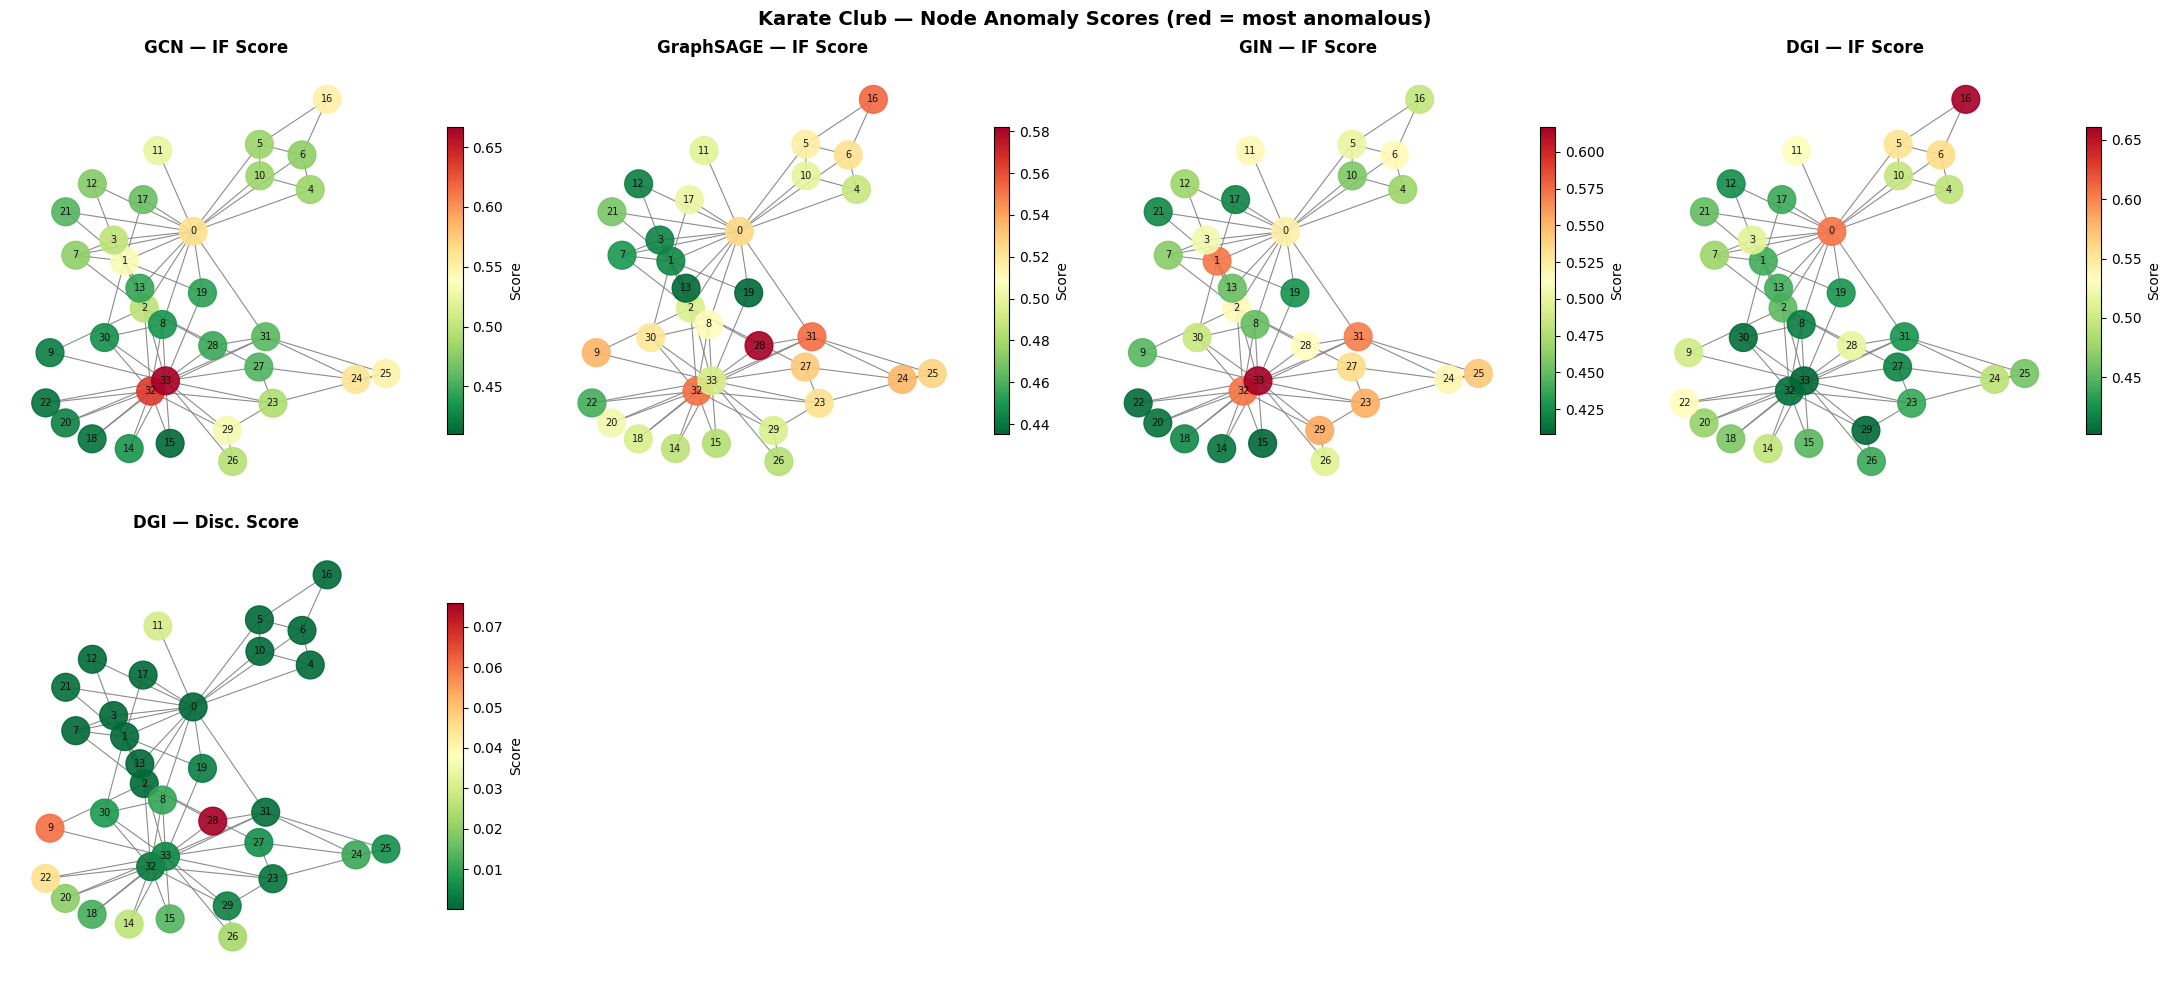

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10))

plot_configs = [
    ('gcn',       None,  'GCN — IF Score'),
    ('graphsage', None,  'GraphSAGE — IF Score'),
    ('gin',       None,  'GIN — IF Score'),
    ('dgi',       None,  'DGI — IF Score'),
    ('dgi',       'disc','DGI — Disc. Score'),
]

for i, (model_name, score_type, title) in enumerate(plot_configs):
    model = karate_models[model_name]
    emb   = model.embed(data_karate.x, data_karate.edge_index).cpu().numpy()

    if score_type == 'disc':
        scores = model.anomaly_score(data_karate.x, data_karate.edge_index).cpu().numpy()
    else:
        scores = isolation_forest_scores(emb)

    row, col = divmod(i, 4)
    ax = axes[row, col]

    # Normalize scores to [0, 1] for color mapping
    norm_scores = (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)
    node_colors = plt.cm.RdYlGn_r(norm_scores)  # red = anomalous, green = normal

    nx.draw_networkx(
        G_karate, pos=pos, ax=ax,
        node_color=node_colors, node_size=400,
        edge_color='gray', alpha=0.9,
        font_size=7, font_color='black', width=0.8
    )
    sm = plt.cm.ScalarMappable(cmap='RdYlGn_r',
                                norm=mcolors.Normalize(vmin=scores.min(), vmax=scores.max()))
    plt.colorbar(sm, ax=ax, shrink=0.7, label='Score')
    ax.set_title(title, fontweight='bold')
    ax.axis('off')

# Hide unused
axes[1, 1].set_visible(False)
axes[1, 2].set_visible(False)
axes[1, 3].set_visible(False)

plt.suptitle('Karate Club — Node Anomaly Scores (red = most anomalous)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('karate_anomaly_visualization.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Part 3: Graph-Level Anomaly Detection on Enzymes
Train models on Enzymes (600 graphs, 6 classes), compute graph-level anomaly scores.

In [10]:
enzymes_models = {}
enzymes_info   = None

for model_name in ['gcn', 'graphsage', 'gin', 'dgi']:
    print(f'Training {model_name.upper()} on Enzymes...')
    model, info = train_model(model_name, 'enzymes', epochs=100, pretrain_epochs=150)
    enzymes_models[model_name] = model
    enzymes_info = info

print('\nCollecting full Enzymes dataset for anomaly scoring...')
from torch_geometric.datasets import TUDataset
full_enzymes = TUDataset(root='../data', name='ENZYMES', use_node_attr=True)

# Build a single DataLoader over all graphs
full_loader = DataLoader(full_enzymes, batch_size=64, shuffle=False)
print(f'Enzymes: {len(full_enzymes)} graphs, {full_enzymes.num_classes} classes')

Training GCN on Enzymes...


  Training GCN (100 epochs)... 

Processing...
Done!


done. Val=0.317, Test=0.267
Training GRAPHSAGE on Enzymes...
  Training GRAPHSAGE (100 epochs)... 

done. Val=0.367, Test=0.167
Training GIN on Enzymes...
  Training GIN (100 epochs)... 

done. Val=0.517, Test=0.383
Training DGI on Enzymes...
  Pre-training DGI (150 epochs)... 

done.
  Training DGI (100 epochs)... 

done. Val=0.200, Test=0.083



Enzymes: 600 graphs, 6 classes


Processing...
Done!


In [11]:
def get_graph_embeddings(model, loader):
    """Get graph-level embeddings for all graphs in the loader."""
    model.eval()
    all_emb, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(DEVICE)
            emb = model.embed(batch.x, batch.edge_index, batch.batch)
            all_emb.append(emb.cpu().numpy())
            all_labels.append(batch.y.cpu().numpy())
    return np.vstack(all_emb), np.concatenate(all_labels)


def get_dgi_graph_anomaly_scores(model, loader):
    """Get DGI discriminator-based anomaly scores for all graphs."""
    model.eval()
    all_scores = []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(DEVICE)
            scores = model.anomaly_score(batch.x, batch.edge_index, batch.batch)
            all_scores.append(scores.cpu().numpy())
    return np.concatenate(all_scores)


print('Extracting graph embeddings...')
enz_embeddings = {}
enz_if_scores  = {}
enz_labels     = None

for model_name, model in enzymes_models.items():
    emb, labels = get_graph_embeddings(model, full_loader)
    enz_embeddings[model_name] = emb
    enz_if_scores[model_name]  = isolation_forest_scores(emb)
    enz_labels = labels
    print(f'  {model_name.upper()}: {emb.shape}')

enz_dgi_disc = get_dgi_graph_anomaly_scores(enzymes_models['dgi'], full_loader)
print(f'\nEnzymes: {len(enz_labels)} graphs, labels range: {enz_labels.min()}–{enz_labels.max()}')

Extracting graph embeddings...
  GCN: (600, 64)


  GRAPHSAGE: (600, 64)
  GIN: (600, 64)


  DGI: (600, 64)

Enzymes: 600 graphs, labels range: 0–5


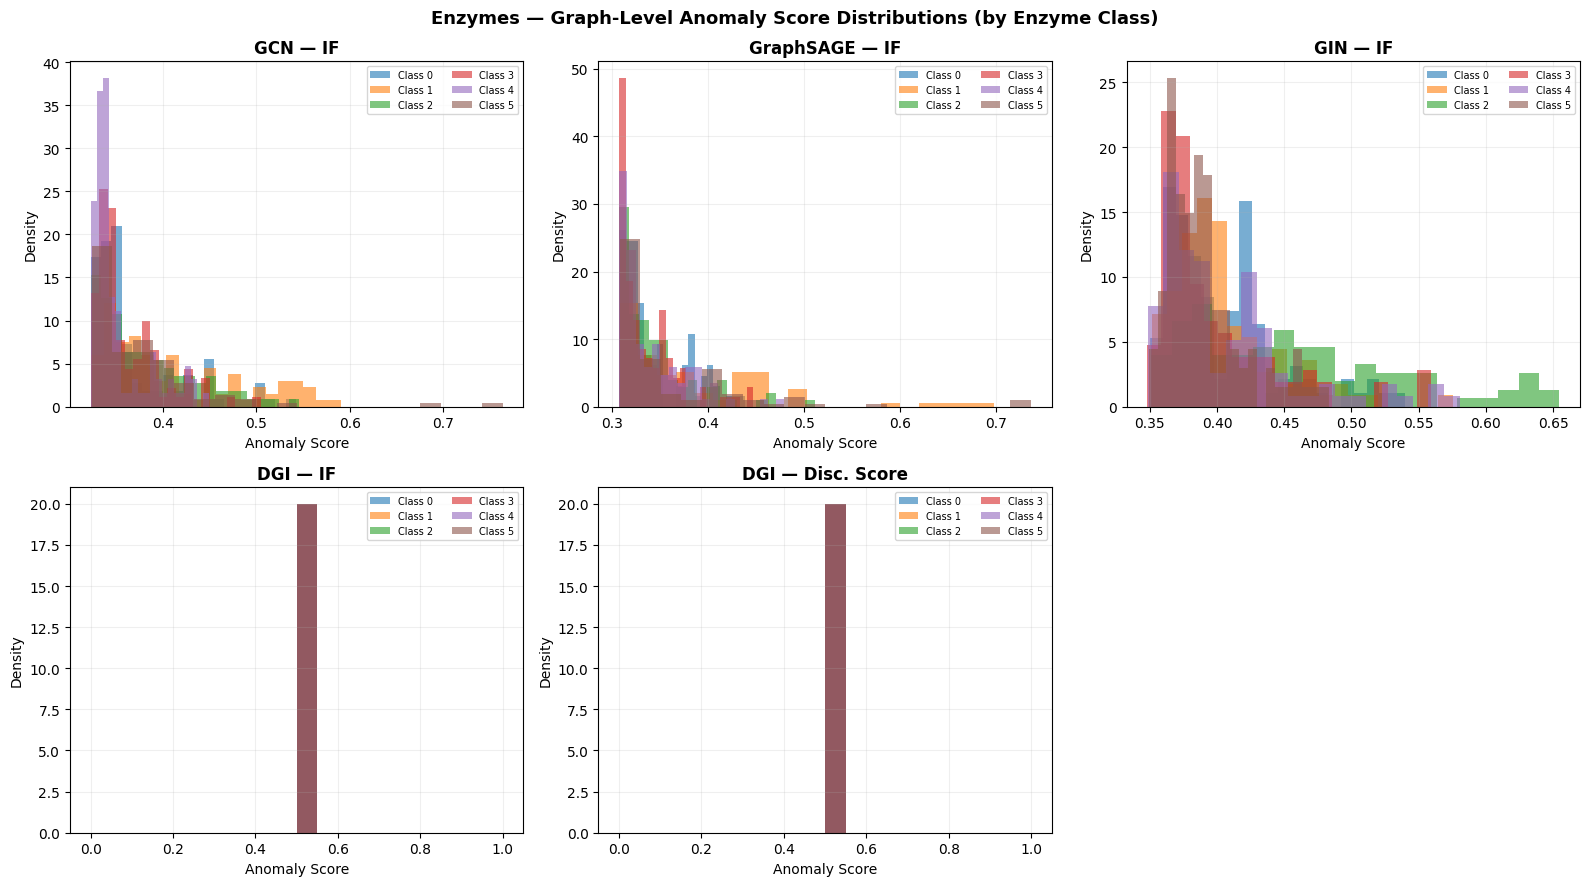

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes_flat  = axes.flat
ENZ_COLORS = plt.cm.tab10.colors[:6]

plot_entries = [
    ('GCN — IF',           enz_if_scores['gcn']),
    ('GraphSAGE — IF',     enz_if_scores['graphsage']),
    ('GIN — IF',           enz_if_scores['gin']),
    ('DGI — IF',           enz_if_scores['dgi']),
    ('DGI — Disc. Score',  enz_dgi_disc),
]

for ax, (title, scores) in zip(axes_flat, plot_entries):
    for cls_idx in range(6):
        mask = enz_labels == cls_idx
        ax.hist(scores[mask], bins=20, alpha=0.6,
                label=f'Class {cls_idx}', color=ENZ_COLORS[cls_idx], density=True)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Anomaly Score')
    ax.set_ylabel('Density')
    ax.legend(fontsize=7, ncol=2)
    ax.grid(True, alpha=0.2)

axes[1, 2].set_visible(False)

plt.suptitle('Enzymes — Graph-Level Anomaly Score Distributions (by Enzyme Class)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('enzymes_anomaly_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

### Top-10 Most Anomalous Graphs (Enzymes)

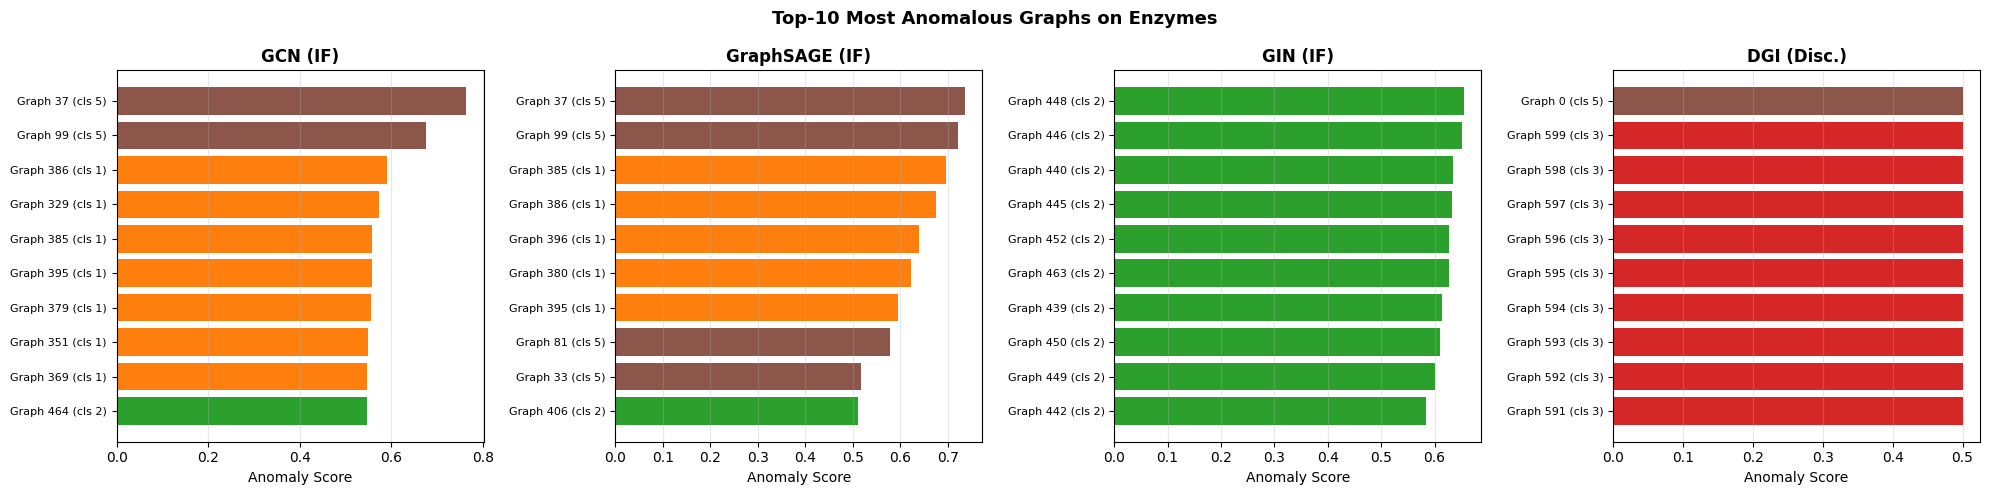

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

enz_all_scores = [
    ('GCN (IF)',       enz_if_scores['gcn']),
    ('GraphSAGE (IF)', enz_if_scores['graphsage']),
    ('GIN (IF)',       enz_if_scores['gin']),
    ('DGI (Disc.)',    enz_dgi_disc),
]

for ax, (title, scores) in zip(axes, enz_all_scores):
    top10_idx = np.argsort(scores)[-10:][::-1]
    top10_cls = enz_labels[top10_idx]
    top10_scr = scores[top10_idx]
    colors_bar = [ENZ_COLORS[c] for c in top10_cls]
    ax.barh(range(10), top10_scr, color=colors_bar)
    ax.set_yticks(range(10))
    ax.set_yticklabels([f'Graph {i} (cls {c})' for i, c in zip(top10_idx, top10_cls)], fontsize=8)
    ax.set_xlabel('Anomaly Score')
    ax.set_title(title, fontweight='bold')
    ax.invert_yaxis()
    ax.grid(True, axis='x', alpha=0.3)

plt.suptitle('Top-10 Most Anomalous Graphs on Enzymes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('enzymes_top10_anomalous.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Part 4: Graph-Level Anomaly Detection on Proteins
Train models on Proteins (1113 graphs, 2 classes — enzyme vs non-enzyme), compute graph-level anomaly scores.

In [14]:
proteins_models = {}
proteins_info   = None

for model_name in ['gcn', 'graphsage', 'gin', 'dgi']:
    print(f'Training {model_name.upper()} on Proteins...')
    model, info = train_model(model_name, 'proteins', epochs=100, pretrain_epochs=150)
    proteins_models[model_name] = model
    proteins_info = info

print('\nCollecting full Proteins dataset for anomaly scoring...')
from torch_geometric.datasets import TUDataset
full_proteins    = TUDataset(root='../data', name='PROTEINS', use_node_attr=True)
full_prot_loader = DataLoader(full_proteins, batch_size=64, shuffle=False)
print(f'Proteins: {len(full_proteins)} graphs, {full_proteins.num_classes} classes')

Training GCN on Proteins...


Processing...


  Training GCN (100 epochs)... 

Done!


done. Val=0.721, Test=0.750
Training GRAPHSAGE on Proteins...
  Training GRAPHSAGE (100 epochs)... 

...

done.
  Training DGI (100 epochs)... 

done. Val=0.577, Test=0.679



Processing...


Proteins: 1113 graphs, 2 classes


Done!


In [15]:
print('Extracting Proteins graph embeddings...')
prot_embeddings = {}
prot_if_scores  = {}
prot_labels     = None

for model_name, model in proteins_models.items():
    emb, labels = get_graph_embeddings(model, full_prot_loader)
    prot_embeddings[model_name] = emb
    prot_if_scores[model_name]  = isolation_forest_scores(emb)
    prot_labels = labels
    print(f'  {model_name.upper()}: {emb.shape}')

prot_dgi_disc = get_dgi_graph_anomaly_scores(proteins_models['dgi'], full_prot_loader)
print(f'\nProteins: {len(prot_labels)} graphs, classes: {sorted(set(prot_labels.tolist()))}')

Extracting Proteins graph embeddings...


  GCN: (1113, 64)


  GRAPHSAGE: (1113, 64)


  GIN: (1113, 64)


  DGI: (1113, 64)

Proteins: 1113 graphs, classes: [0, 1]


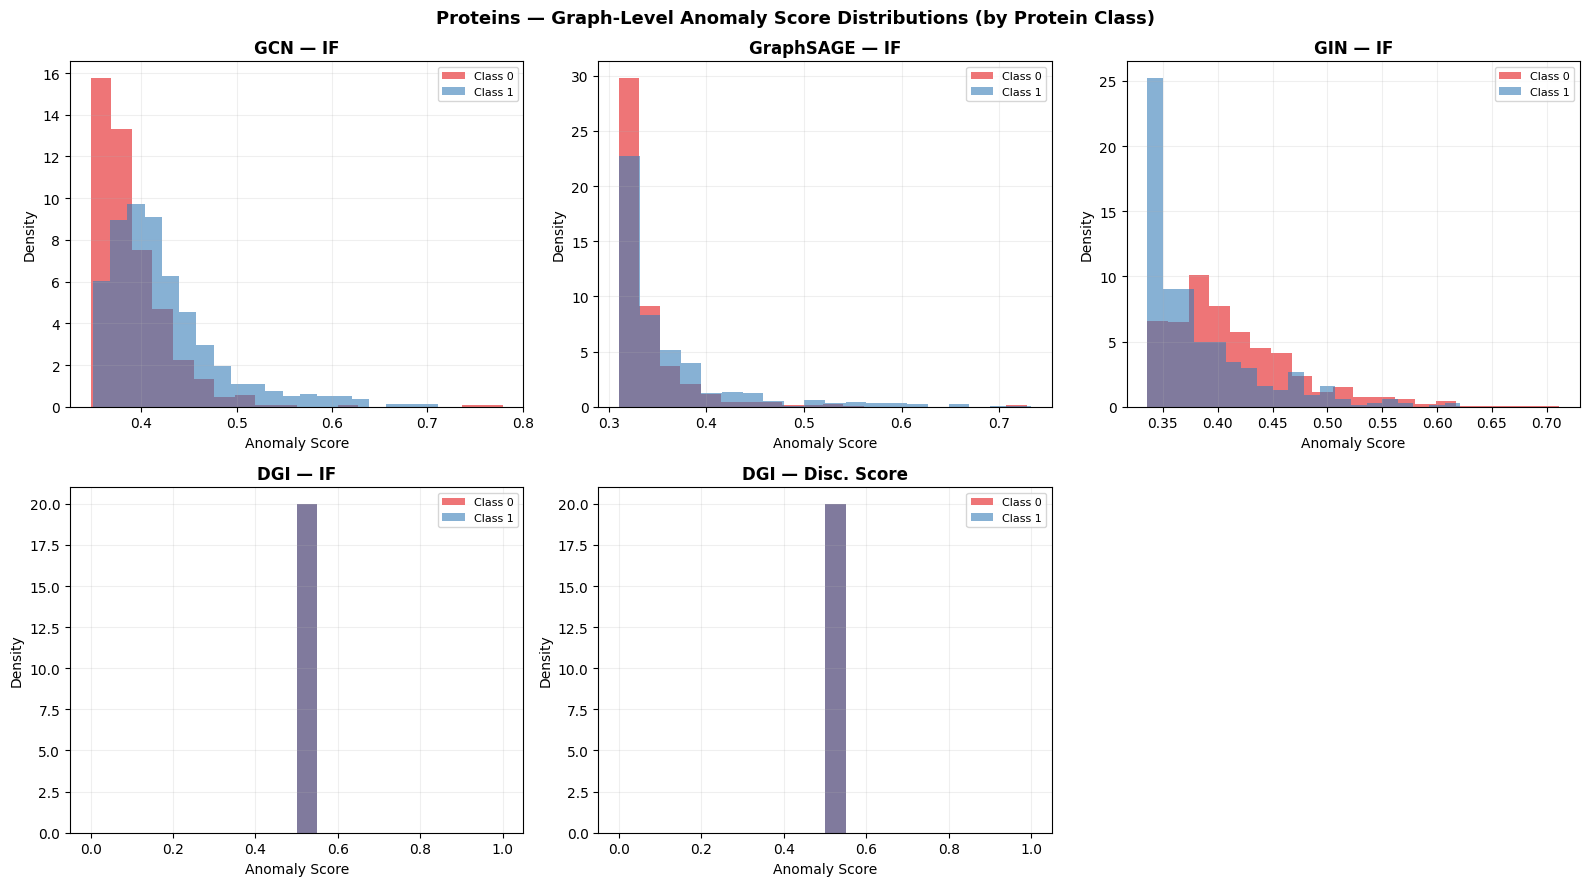

In [16]:
PROT_COLORS = plt.cm.Set1.colors[:2]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes_flat  = axes.flat

plot_entries_prot = [
    ('GCN — IF',           prot_if_scores['gcn']),
    ('GraphSAGE — IF',     prot_if_scores['graphsage']),
    ('GIN — IF',           prot_if_scores['gin']),
    ('DGI — IF',           prot_if_scores['dgi']),
    ('DGI — Disc. Score',  prot_dgi_disc),
]

for ax, (title, scores) in zip(axes_flat, plot_entries_prot):
    for cls_idx in range(2):
        mask = prot_labels == cls_idx
        ax.hist(scores[mask], bins=20, alpha=0.6,
                label=f'Class {cls_idx}', color=PROT_COLORS[cls_idx], density=True)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Anomaly Score')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)

axes[1, 2].set_visible(False)

plt.suptitle('Proteins — Graph-Level Anomaly Score Distributions (by Protein Class)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('proteins_anomaly_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

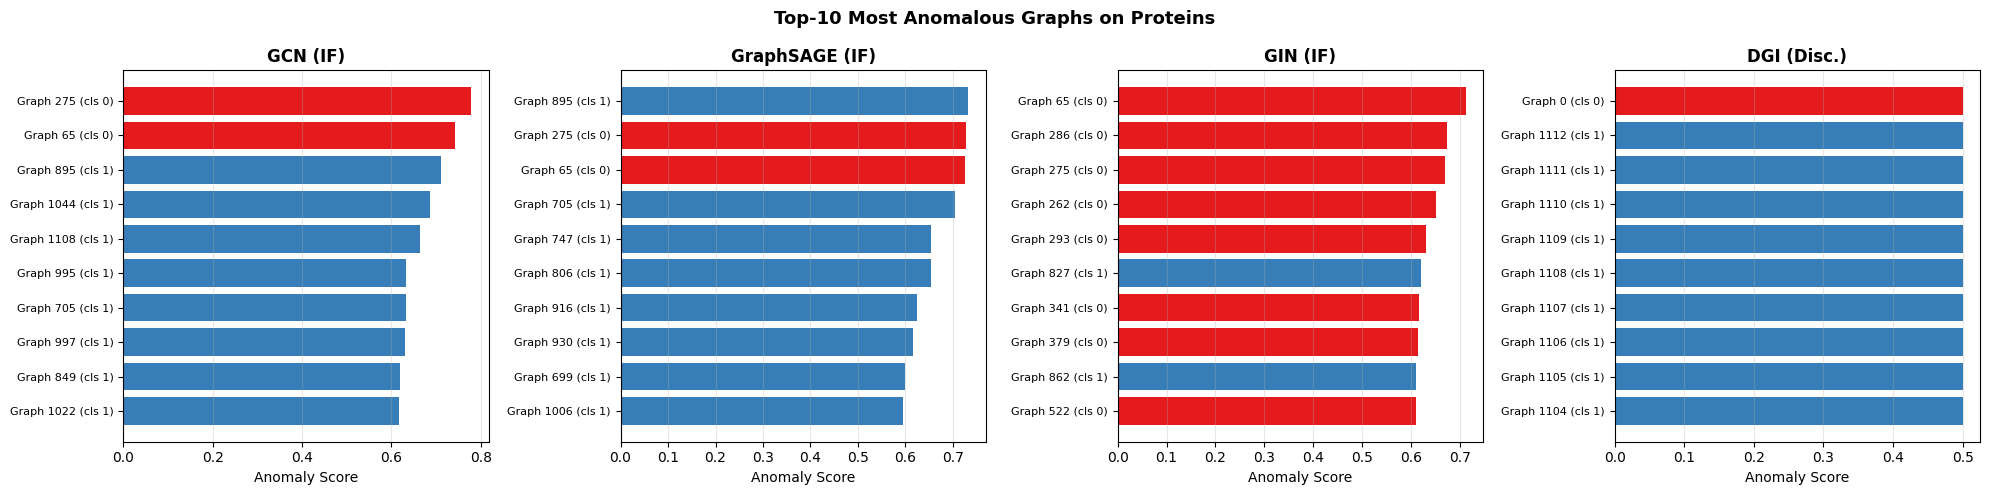

In [17]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

prot_all_scores = [
    ('GCN (IF)',       prot_if_scores['gcn']),
    ('GraphSAGE (IF)', prot_if_scores['graphsage']),
    ('GIN (IF)',       prot_if_scores['gin']),
    ('DGI (Disc.)',    prot_dgi_disc),
]

for ax, (title, scores) in zip(axes, prot_all_scores):
    top10_idx  = np.argsort(scores)[-10:][::-1]
    top10_cls  = prot_labels[top10_idx]
    top10_scr  = scores[top10_idx]
    colors_bar = [PROT_COLORS[c] for c in top10_cls]
    ax.barh(range(10), top10_scr, color=colors_bar)
    ax.set_yticks(range(10))
    ax.set_yticklabels([f'Graph {i} (cls {c})' for i, c in zip(top10_idx, top10_cls)], fontsize=8)
    ax.set_xlabel('Anomaly Score')
    ax.set_title(title, fontweight='bold')
    ax.invert_yaxis()
    ax.grid(True, axis='x', alpha=0.3)

plt.suptitle('Top-10 Most Anomalous Graphs on Proteins', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('proteins_top10_anomalous.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Summary

| Dataset | Task | Models | Anomaly method |
|---|---|---|---|
| Cora | Node-level | GCN, GraphSAGE, GIN, DGI | Isolation Forest on embeddings; DGI also uses discriminator score |
| Karate | Node-level + graph viz | GCN, GraphSAGE, GIN, DGI | Isolation Forest + NetworkX color visualization |
| Enzymes | Graph-level | GCN, GraphSAGE, GIN, DGI | Isolation Forest on graph embeddings; DGI also uses discriminator score |
| Proteins | Graph-level | GCN, GraphSAGE, GIN, DGI | Isolation Forest on graph embeddings; DGI also uses discriminator score |

| Approach | Models | Score source | Best for |
|---|---|---|---|
| Isolation Forest | GCN, GraphSAGE, GIN, DGI | `embed()` embeddings | Any model, any task |
| Discriminator score | DGI only | `anomaly_score()` | Node/graph tasks; no labels needed even at inference |

**Key observations:**
- DGI's discriminator and Isolation Forest scores should correlate when the encoder has learned meaningful structure.
- Anomalous nodes/graphs often sit at the boundary between communities or classes.
- Karate Club visualization: nodes near the structural boundary typically score highest.
- Proteins (binary classification) shows clearer class separation in anomaly scores than Enzymes (6 classes).